In [ ]:
#Name - Atharv Kashiv
#roll - 2501940030


# ================================
# EXPERIMENT 2: CNN
# ================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

# Load data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.7739 - loss: 0.6326 - val_accuracy: 0.8527 - val_loss: 0.3981
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8474 - loss: 0.4209 - val_accuracy: 0.8743 - val_loss: 0.3423
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.8669 - loss: 0.3682 - val_accuracy: 0.8824 - val_loss: 0.3166
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8789 - loss: 0.3350 - val_accuracy: 0.8947 - val_loss: 0.2840
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.8896 - loss: 0.3057 - val_accuracy: 0.8966 - val_loss: 0.2776
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.8947 - loss: 0.2891 - val_accuracy: 0.9003 - val_loss: 0.2668
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9009 - loss: 0.2685 - val_accuracy: 0.9095 - val_loss: 0.2489
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9081 - loss: 0.2514 - 

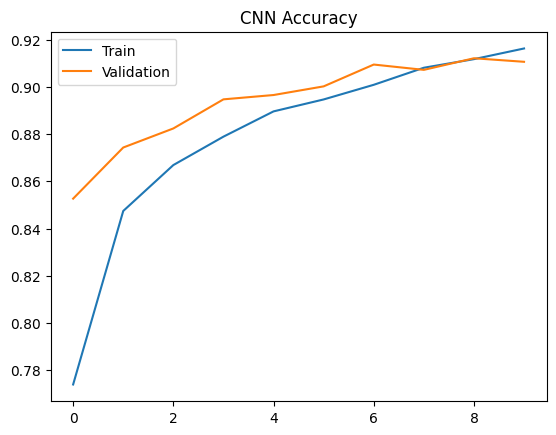

In [3]:
# ================================
# Model
# ================================
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train,y_train,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=64)

# Evaluate
loss, acc = model.evaluate(X_test,y_test)
print("Accuracy:",acc)

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Metrics
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.legend(['Train','Validation'])
plt.show()